In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [4]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

sample_funds = nav_history["amfi_code"].unique()[:10]

plot_df = nav_history[
    nav_history["amfi_code"].isin(sample_funds)
]

fig = px.line(
    plot_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trends (2022-2026)"
)

fig.show()

In [7]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

print(aum[["date", "year"]].head())

        date  year
0 2022-03-31  2022
1 2022-03-31  2022
2 2022-03-31  2022
3 2022-03-31  2022
4 2022-03-31  2022


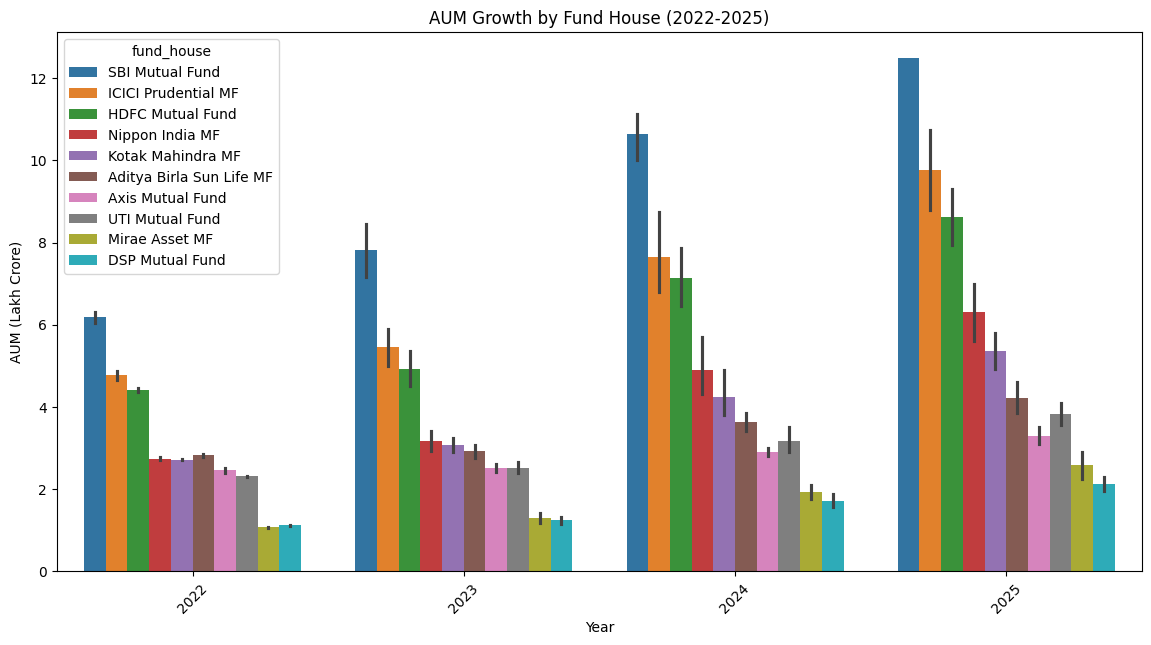

In [8]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)

plt.show()

Insight 1:
SBI Mutual Fund maintains one of the highest AUM levels among fund houses, indicating strong investor trust and market presence.

In [14]:
sip.head()
print(sip.columns.tolist())
sip["month"] = pd.to_datetime(sip["month"])

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [15]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

fig.show()

In [19]:
max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [20]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)",
    markers=True
)

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="All-Time High ₹31,002 Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

Insight 2:
Monthly SIP inflows increased consistently from 2022 to 2025, reaching an all-time high of ₹31,002 Cr in December 2025, reflecting strong retail investor participation in mutual funds.

In [21]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


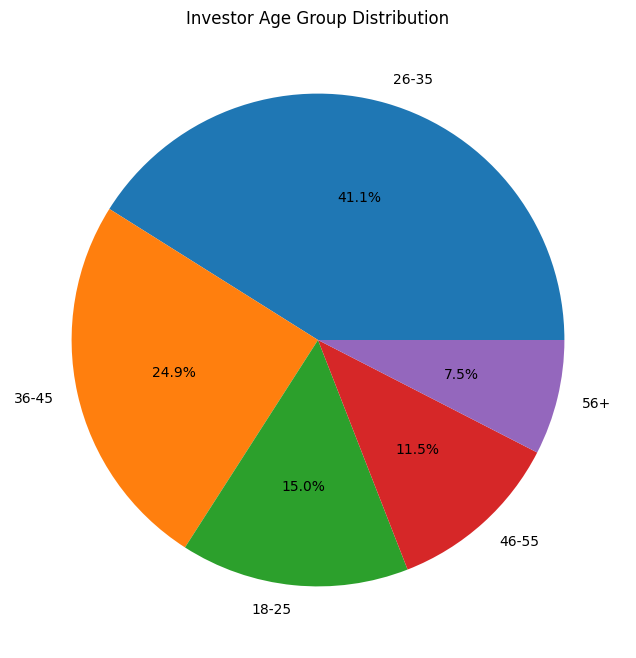

In [22]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

Insight 3:
The 26–35 age group forms the largest investor segment with 13,463 investors, indicating strong mutual fund adoption among young professionals.

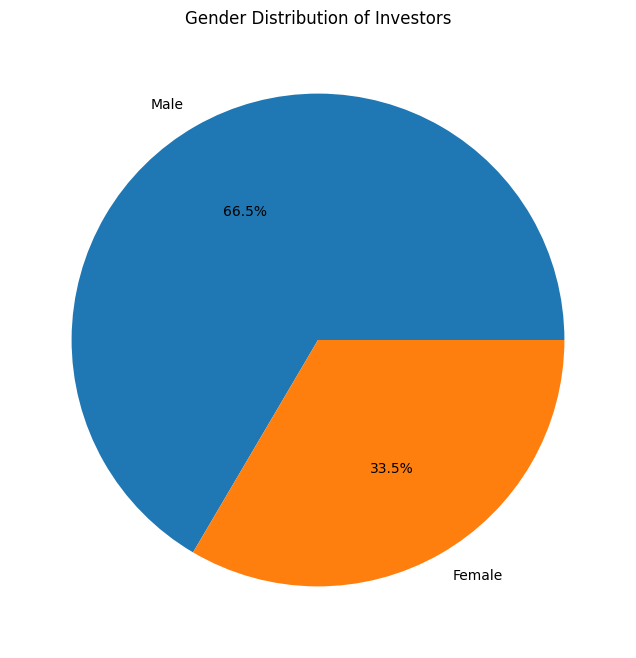

In [23]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")

plt.show()

Insight 4:
Investors aged 26–45 account for the majority of mutual fund participation, highlighting the importance of the mid-career demographic.

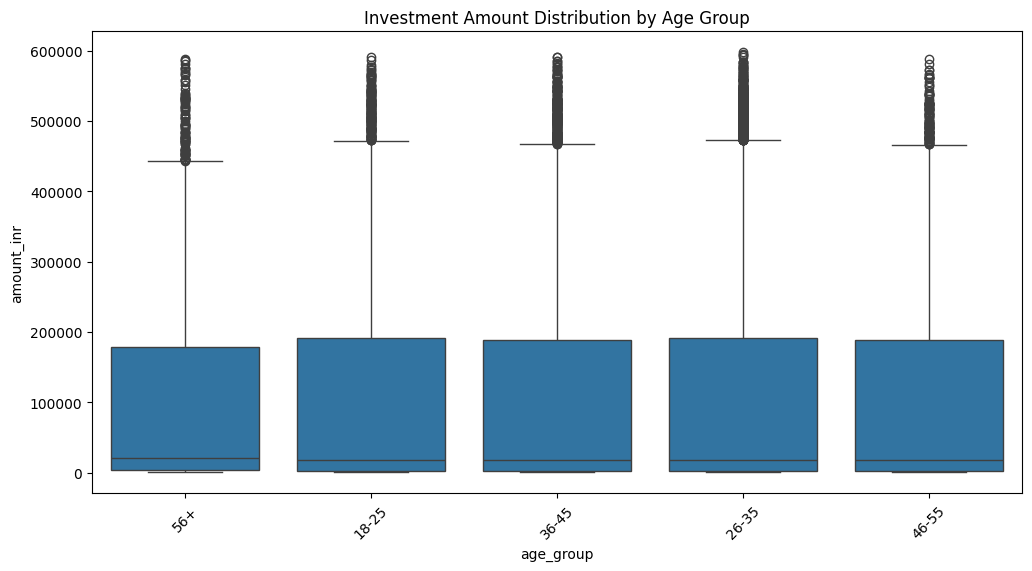

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")

plt.xticks(rotation=45)

plt.show()

Insight 5:
Male investors account for 21,809 of the 32,778 investors (~66.5%), while female investors account for 10,969 (~33.5%). This indicates a significant gender gap in mutual fund participation.

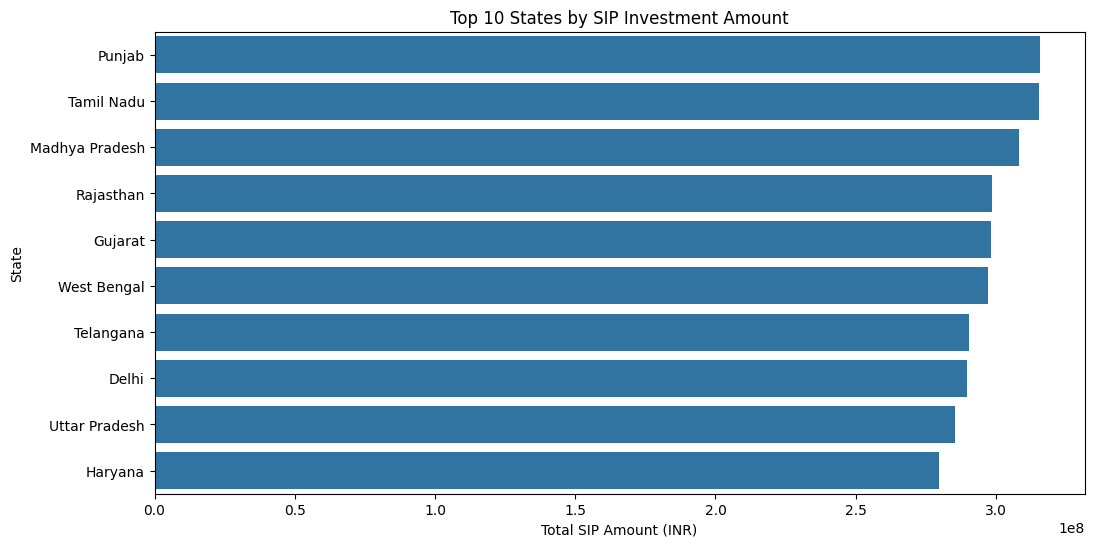

In [25]:
state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_amount.values,
    y=state_amount.index
)

plt.title("Top 10 States by SIP Investment Amount")

plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.show()

Insight 6:
Although male investors dominate the investor base, female participation represents one-third of all investors, highlighting a growing opportunity for targeted financial inclusion and investment awareness programs.

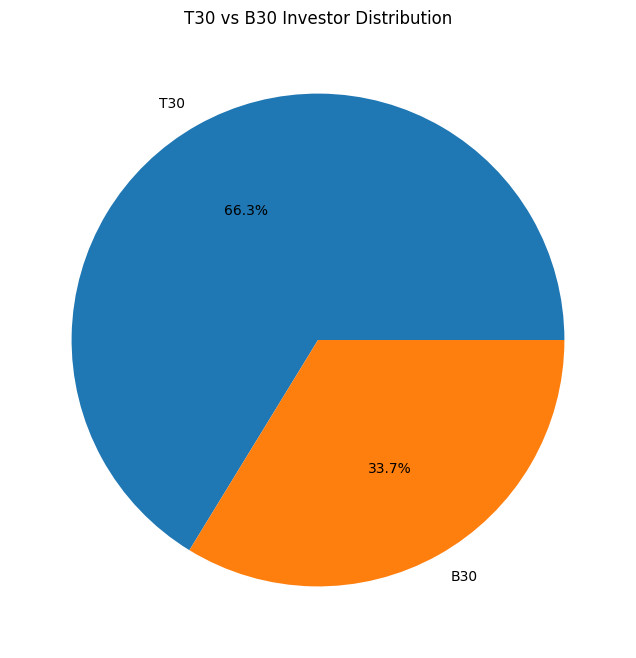

In [26]:
tier_counts = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

Insight 7:
Investors from both T30 and B30 cities contribute to mutual fund growth, indicating expanding market penetration beyond major metropolitan regions.

In [27]:
transactions["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

In [28]:
transactions["gender"].value_counts()

gender
Male      21809
Female    10969
Name: count, dtype: int64